In [46]:
import numpy as np
import pandas as pd


In [47]:
df = pd.read_csv('data/diagnosed_cbc_data_v4.csv')
df.head(5)

,WBC,LYMp,NEUTp,LYMn,NEUTn,RBC,HGB,HCT,MCV,MCH,MCHC,PLT,PDW,PCT,Diagnosis
0,10.0,43.2,50.1,4.3,5.0,2.77,7.3,24.2,87.7,26.3,30.1,189.0,12.5,0.17,Normocytic hypochromic anemia
1,10.0,42.4,52.3,4.2,5.3,2.84,7.3,25.0,88.2,25.7,20.2,180.0,12.5,0.16,Normocytic hypochromic anemia
2,7.2,30.7,60.7,2.2,4.4,3.97,9.0,30.5,77.0,22.6,29.5,148.0,14.3,0.14,Iron deficiency anemia
3,6.0,30.2,63.5,1.8,3.8,4.22,3.8,32.8,77.9,23.2,29.8,143.0,11.3,0.12,Iron deficiency anemia
4,4.2,39.1,53.7,1.6,2.3,3.93,0.4,316.0,80.6,23.9,29.7,236.0,12.8,0.22,Normocytic hypochromic anemia


In [48]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import to_categorical


In [49]:
y=df['Diagnosis']
x=df.drop('Diagnosis',axis=1)


In [50]:
y

0       Normocytic hypochromic anemia
1       Normocytic hypochromic anemia
2              Iron deficiency anemia
3              Iron deficiency anemia
4       Normocytic hypochromic anemia
                    ...              
1276                          Healthy
1277                          Healthy
1278                          Healthy
1279                          Healthy
1280                          Healthy
Name: Diagnosis, Length: 1281, dtype: object

In [51]:

le = LabelEncoder()

y_encoded = le.fit_transform(df['Diagnosis']) # Önce LabelEncoder ile sayısal değerlere dönüştürelim

y_categorical = to_categorical(y_encoded) # Sonra one-hot encoding yapalım


# Hangi sayısal değerin hangi tanıya karşılık geldiğini görmek için:
for i, diagnosis in enumerate(le.classes_):
    print(f"{i}: {diagnosis}")


0: Healthy
1: Iron deficiency anemia
2: Leukemia
3: Leukemia with thrombocytopenia
4: Macrocytic anemia
5: Normocytic hypochromic anemia
6: Normocytic normochromic anemia
7: Other microcytic anemia
8: Thrombocytopenia


In [54]:
y_categorical

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]], shape=(1281, 9))

In [52]:
le.inverse_transform([4])

array(['Macrocytic anemia'], dtype=object)

In [53]:
y.shape[1] # çıktı boyutunu görmemizi sağlıyor

IndexError: tuple index out of range

In [55]:
x_train,x_test,y_train,y_test = train_test_split(x,y_categorical,train_size=0.75,random_state=42)


In [67]:
from keras.layers import Input

model = Sequential([
    Input(shape=(14,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(16, activation='relu'),
    Dense(64, activation='relu'),
    Dense(9, activation="softmax")
])


In [77]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Precision, Recall, AUC

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy', Precision(name='precision'), Recall(name='recall'), AUC(name='auc')]
)



In [78]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    validation_split=0.2,   # eğitim verisinin %20’si doğrulama için ayrılır
    epochs=100,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.7772 - auc: 0.9754 - loss: 0.6333 - precision: 0.8377 - recall: 0.7093 - val_accuracy: 0.6927 - val_auc: 0.9449 - val_loss: 15.1919 - val_precision: 0.7736 - val_recall: 0.6406
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7982 - auc: 0.9822 - loss: 0.5390 - precision: 0.8524 - recall: 0.7423 - val_accuracy: 0.7031 - val_auc: 0.9497 - val_loss: 15.9507 - val_precision: 0.7697 - val_recall: 0.6615
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8486 - auc: 0.9885 - loss: 0.4411 - precision: 0.8988 - recall: 0.7764 - val_accuracy: 0.7292 - val_auc: 0.9464 - val_loss: 17.0729 - val_precision: 0.7791 - val_recall: 0.6615
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8255 - auc: 0.9858 - loss: 0.4771 - precision: 0.8720 - recall: 0.7867 - val_accuracy: 0.7240 - val_auc: 0.9492 - val_loss: 17.3352 - val_precision: 0.7798 - val_recall: 0.6823
Epoch 5/100
24/24 ━━━━━━━━━━━━━

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Sınıflandırma Raporu:
                                precision    recall  f1-score   support

                       Healthy       0.91      0.87      0.89       103
        Iron deficiency anemia       0.85      0.87      0.86        46
                      Leukemia       0.00      0.00      0.00         6
Leukemia with thrombocytopenia       0.00      0.00      0.00         3
             Macrocytic anemia       0.33      0.50      0.40         2
 Normocytic hypochromic anemia       0.70      0.80      0.75        71
Normocytic normochromic anemia       0.78      0.69      0.73        55
       Other microcytic anemia       0.88      0.47      0.61        15
              Thrombocytopenia       0.63      0.85      0.72        20

                      accuracy                           0.78       321
                     macro avg       0.56      0.56      0.55       321
                  weighted avg       0.78      0.78      0.78       321


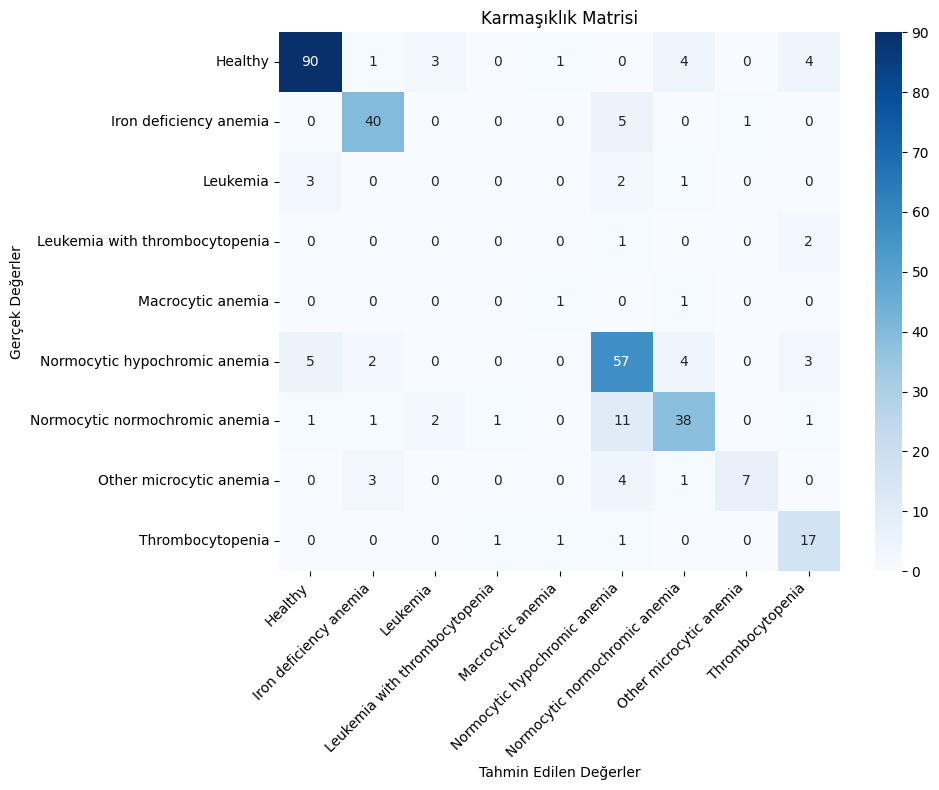


Genel Test Doğruluk Oranı: %77.88


In [79]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Tahminleri yapalım
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Sınıflandırma raporunu alalım
print("\nSınıflandırma Raporu:")
print(classification_report(y_test_classes, y_pred_classes,
                          target_names=le.classes_,
                          zero_division=0))

# Karmaşıklık matrisini görselleştirelim
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.title('Karmaşıklık Matrisi')
plt.ylabel('Gerçek Değerler')
plt.xlabel('Tahmin Edilen Değerler')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Genel doğruluk oranı
accuracy = np.mean(y_pred_classes == y_test_classes)
print(f'\nGenel Test Doğruluk Oranı: %{accuracy * 100:.2f}')